In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

In [36]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [37]:
def precision_score(y_true, y_pred):

    classes = np.unique(y_true)

    precisions = []

    for cls in classes:

        TP = np.sum((y_true == cls) & (y_pred == cls))

        FP = np.sum((y_true != cls) & (y_pred == cls))

        if TP + FP == 0:
            precision = 0
        else:
            precision = TP / (TP + FP)

        precisions.append(precision)

    return np.mean(precisions)

In [38]:
def recall_score(y_true, y_pred):

    classes = np.unique(y_true)

    recalls = []

    for cls in classes:

        TP = np.sum((y_true == cls) & (y_pred == cls))

        FN = np.sum((y_true == cls) & (y_pred != cls))

        if TP + FN == 0:
            recall = 0
        else:
            recall = TP / (TP + FN)

        recalls.append(recall)

    return np.mean(recalls)

In [39]:
def f1_score(y_true, y_pred):

    classes = np.unique(y_true)

    f1s = []

    for cls in classes:

        TP = np.sum((y_true == cls) & (y_pred == cls))

        FP = np.sum((y_true != cls) & (y_pred == cls))

        FN = np.sum((y_true == cls) & (y_pred != cls))

        if TP + FP == 0:
            precision = 0
        else:
            precision = TP / (TP + FP)

        if TP + FN == 0:
            recall = 0
        else:
            recall = TP / (TP + FN)

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = (
                2 * precision * recall /
                (precision + recall)
            )

        f1s.append(f1)

    return np.mean(f1s)

In [40]:
data = np.loadtxt("californiabin.csv", delimiter=",")

X = data[:, :-1]
y = data[:, -1]

In [41]:
def train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=None,
    shuffle=True,
    stratify=False
):

    rng = np.random.default_rng(random_state)

    if stratify:

        classes = np.unique(y)

        train_indices = []
        test_indices = []

        for c in classes:

            class_indices = np.where(y == c)[0]

            if shuffle:
                rng.shuffle(class_indices)

            n_test = int(len(class_indices) * test_size)

            test_class = class_indices[:n_test]
            train_class = class_indices[n_test:]

            test_indices.extend(test_class)
            train_indices.extend(train_class)

        train_indices = np.array(train_indices)
        test_indices = np.array(test_indices)

        if shuffle:
            rng.shuffle(train_indices)
            rng.shuffle(test_indices)

    else:

        indices = np.arange(len(X))

        if shuffle:
            rng.shuffle(indices)

        n_test = int(len(X) * test_size)

        test_indices = indices[:n_test]
        train_indices = indices[n_test:]

    X_train = X[train_indices]
    X_test = X[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test

In [42]:
class KFold:

    def __init__(
        self,
        n_splits=10,
        shuffle=True,
        random_state=None
    ):

        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):

        n_samples = len(X)

        indices = np.arange(n_samples)

        if self.shuffle:
            rng = np.random.default_rng(self.random_state)
            rng.shuffle(indices)

        fold_sizes = np.full(
            self.n_splits,
            n_samples // self.n_splits,
            dtype=int
        )

        fold_sizes[:n_samples % self.n_splits] += 1

        current = 0

        for fold_size in fold_sizes:

            start = current
            stop = current + fold_size

            val_indices = indices[start:stop]

            train_indices = np.concatenate(
                (
                    indices[:start],
                    indices[stop:]
                )
            )

            yield train_indices, val_indices

            current = stop

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=True
)

In [44]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

std[std == 0] = 1.0

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

In [45]:
def cross_validation_score(model_class, params,
                           X, y,
                           n_splits=10):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in kf.split(X):

        X_tr = X[train_idx]
        X_val = X[val_idx]

        y_tr = y[train_idx]
        y_val = y[val_idx]

        model = model_class(**params)

        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)

        scores.append(acc)

    return np.mean(scores)

In [46]:
C_values = [2**i for i in range(-5, 16, 2)]
gamma_values = [2**i for i in range(-15, 4, 2)]

best_svm_score = -np.inf
best_svm_params = None

svm_results = []

In [47]:
for C, gamma in product(C_values, gamma_values):

    params = {
        "C": C,
        "gamma": gamma,
        "kernel": "rbf"
    }

    score = cross_validation_score(
        SVC,
        params,
        X_train_norm,
        y_train
    )

    svm_results.append((C, gamma, score))

    print(f"C={C:<8} gamma={gamma:<12} "
          f"CV Accuracy={score:.4f}")

    if score > best_svm_score:
        best_svm_score = score
        best_svm_params = params

C=0.03125  gamma=3.0517578125e-05 CV Accuracy=0.4600
C=0.03125  gamma=0.0001220703125 CV Accuracy=0.4600
C=0.03125  gamma=0.00048828125 CV Accuracy=0.4600
C=0.03125  gamma=0.001953125  CV Accuracy=0.4600
C=0.03125  gamma=0.0078125    CV Accuracy=0.6619
C=0.03125  gamma=0.03125      CV Accuracy=0.7956
C=0.03125  gamma=0.125        CV Accuracy=0.8175
C=0.03125  gamma=0.5          CV Accuracy=0.8088
C=0.03125  gamma=2            CV Accuracy=0.4669
C=0.03125  gamma=8            CV Accuracy=0.4600
C=0.125    gamma=3.0517578125e-05 CV Accuracy=0.4600
C=0.125    gamma=0.0001220703125 CV Accuracy=0.4600
C=0.125    gamma=0.00048828125 CV Accuracy=0.4600
C=0.125    gamma=0.001953125  CV Accuracy=0.6763
C=0.125    gamma=0.0078125    CV Accuracy=0.8025
C=0.125    gamma=0.03125      CV Accuracy=0.8294
C=0.125    gamma=0.125        CV Accuracy=0.8287
C=0.125    gamma=0.5          CV Accuracy=0.8306
C=0.125    gamma=2            CV Accuracy=0.7506
C=0.125    gamma=8            CV Accuracy=0.4600
C=0.

In [48]:
best_svm = SVC(
    **best_svm_params,
    probability=True
)

best_svm.fit(X_train_norm, y_train)

SVC(C=32, gamma=0.03125, probability=True)

In [49]:
y_pred_svm = best_svm.predict(X_test_norm)
y_prob_svm = best_svm.predict_proba(X_test_norm)[:, 1]

In [50]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

In [51]:
print("\n" + "="*60)
print("RESULTADOS SVM")
print("="*60)

print(f"Acurácia : {acc_svm:.4f}")
print(f"Precisão : {prec_svm:.4f}")
print(f"Revocação: {rec_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")


RESULTADOS SVM
Acurácia : 0.8375
Precisão : 0.8377
Revocação: 0.8375
F1-score : 0.8375


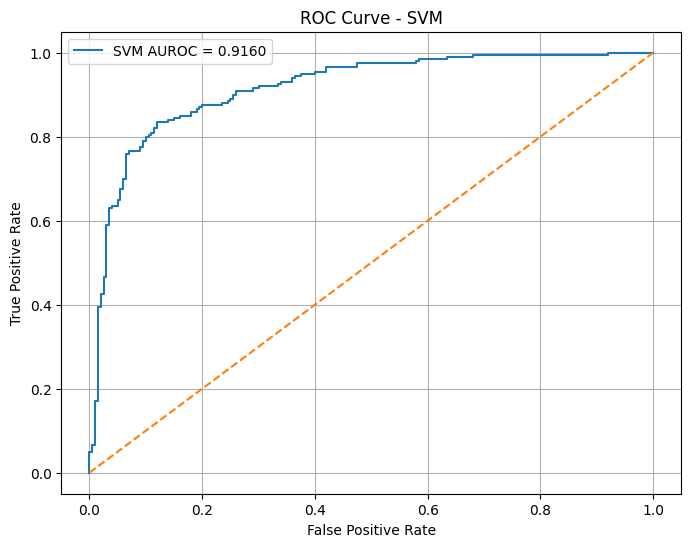

In [52]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auroc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))

plt.plot(fpr_svm, tpr_svm,
         label=f"SVM AUROC = {auroc_svm:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")

plt.legend()
plt.grid()

plt.show()

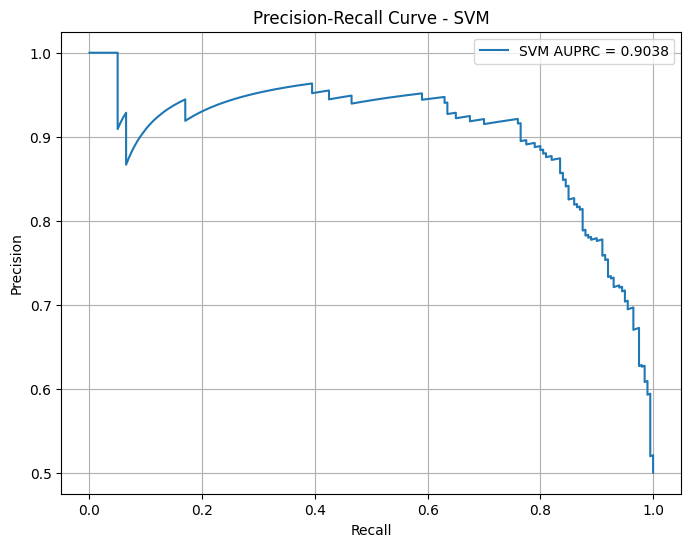

In [53]:
precision_svm, recall_svm, _ = precision_recall_curve(
    y_test,
    y_prob_svm
)

auprc_svm = auc(recall_svm, precision_svm)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_svm,
    precision_svm,
    label=f"SVM AUPRC = {auprc_svm:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - SVM")

plt.legend()
plt.grid()

plt.show()

In [54]:
print(f"\nAUROC SVM: {auroc_svm:.4f}")
print(f"AUPRC SVM: {auprc_svm:.4f}")

print("\n" + "="*60)
print("GRID SEARCH - RANDOM FOREST")
print("="*60)


AUROC SVM: 0.9160
AUPRC SVM: 0.9038

GRID SEARCH - RANDOM FOREST


In [55]:
n_estimators_values = list(range(10, 201, 10))
max_depth_values = [4, 6, 8, 10, None]

best_rf_score = -np.inf
best_rf_params = None

rf_results = []

In [56]:
for n_estimators, max_depth in product(
    n_estimators_values,
    max_depth_values
):

    params = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "random_state": 42,
        "n_jobs": -1
    }

    score = cross_validation_score(
        RandomForestClassifier,
        params,
        X_train_norm,
        y_train
    )

    rf_results.append((n_estimators, max_depth, score))

    print(f"Trees={n_estimators:<4} "
          f"Depth={str(max_depth):<5} "
          f"CV Accuracy={score:.4f}")

    if score > best_rf_score:
        best_rf_score = score
        best_rf_params = params

Trees=10   Depth=4     CV Accuracy=0.8138
Trees=10   Depth=6     CV Accuracy=0.8244
Trees=10   Depth=8     CV Accuracy=0.8350
Trees=10   Depth=10    CV Accuracy=0.8444
Trees=10   Depth=None  CV Accuracy=0.8400
Trees=20   Depth=4     CV Accuracy=0.8231
Trees=20   Depth=6     CV Accuracy=0.8400
Trees=20   Depth=8     CV Accuracy=0.8400
Trees=20   Depth=10    CV Accuracy=0.8525
Trees=20   Depth=None  CV Accuracy=0.8631
Trees=30   Depth=4     CV Accuracy=0.8231
Trees=30   Depth=6     CV Accuracy=0.8444
Trees=30   Depth=8     CV Accuracy=0.8500
Trees=30   Depth=10    CV Accuracy=0.8606
Trees=30   Depth=None  CV Accuracy=0.8656
Trees=40   Depth=4     CV Accuracy=0.8275
Trees=40   Depth=6     CV Accuracy=0.8475
Trees=40   Depth=8     CV Accuracy=0.8494
Trees=40   Depth=10    CV Accuracy=0.8569
Trees=40   Depth=None  CV Accuracy=0.8675
Trees=50   Depth=4     CV Accuracy=0.8225
Trees=50   Depth=6     CV Accuracy=0.8519
Trees=50   Depth=8     CV Accuracy=0.8525
Trees=50   Depth=10    CV Accuracy

In [57]:
print("\nMelhor configuração Random Forest:")
print(best_rf_params)
print(f"Melhor Accuracy CV: {best_rf_score:.4f}")


Melhor configuração Random Forest:
{'n_estimators': 140, 'max_depth': None, 'random_state': 42, 'n_jobs': -1}
Melhor Accuracy CV: 0.8744


In [58]:
best_rf = RandomForestClassifier(**best_rf_params)

best_rf.fit(X_train_norm, y_train)

y_pred_rf = best_rf.predict(X_test_norm)
y_prob_rf = best_rf.predict_proba(X_test_norm)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [59]:
print("\n" + "="*60)
print("RESULTADOS RANDOM FOREST")
print("="*60)

print(f"Acurácia : {acc_rf:.4f}")
print(f"Precisão : {prec_rf:.4f}")
print(f"Revocação: {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")


RESULTADOS RANDOM FOREST
Acurácia : 0.8725
Precisão : 0.8727
Revocação: 0.8725
F1-score : 0.8725


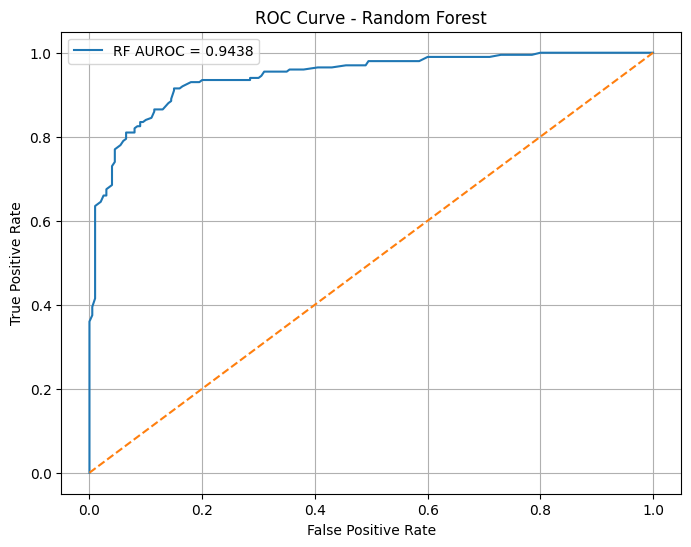

In [60]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auroc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"RF AUROC = {auroc_rf:.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()
plt.grid()

plt.show()

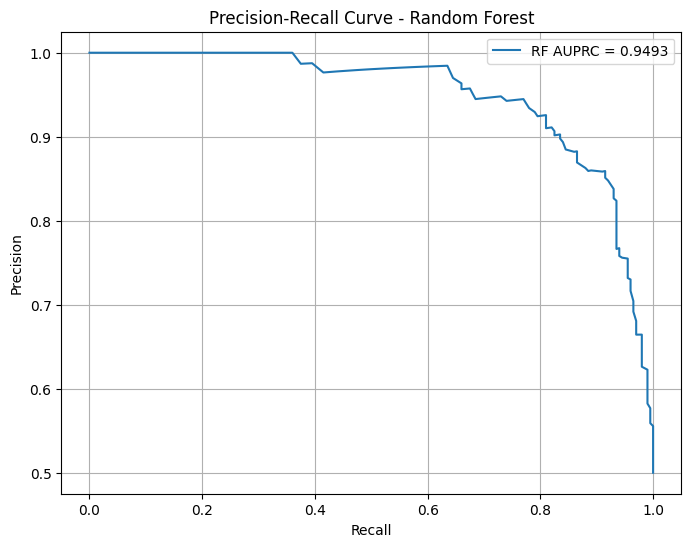

In [61]:
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

auprc_rf = auc(recall_rf, precision_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_rf,
    precision_rf,
    label=f"RF AUPRC = {auprc_rf:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Random Forest")

plt.legend()
plt.grid()

plt.show()

In [62]:
print(f"\nAUROC RF: {auroc_rf:.4f}")
print(f"AUPRC RF: {auprc_rf:.4f}")

print("\n" + "="*60)
print("COMPARAÇÃO FINAL")
print("="*60)

print("\nSVM")
print(best_svm_params)

print(f"Acurácia : {acc_svm:.4f}")
print(f"Precisão : {prec_svm:.4f}")
print(f"Revocação: {rec_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")
print(f"AUROC    : {auroc_svm:.4f}")
print(f"AUPRC    : {auprc_svm:.4f}")

print("\nRandom Forest")
print(best_rf_params)

print(f"Acurácia : {acc_rf:.4f}")
print(f"Precisão : {prec_rf:.4f}")
print(f"Revocação: {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"AUROC    : {auroc_rf:.4f}")
print(f"AUPRC    : {auprc_rf:.4f}")


AUROC RF: 0.9438
AUPRC RF: 0.9493

COMPARAÇÃO FINAL

SVM
{'C': 32, 'gamma': 0.03125, 'kernel': 'rbf'}
Acurácia : 0.8375
Precisão : 0.8377
Revocação: 0.8375
F1-score : 0.8375
AUROC    : 0.9160
AUPRC    : 0.9038

Random Forest
{'n_estimators': 140, 'max_depth': None, 'random_state': 42, 'n_jobs': -1}
Acurácia : 0.8725
Precisão : 0.8727
Revocação: 0.8725
F1-score : 0.8725
AUROC    : 0.9438
AUPRC    : 0.9493
